In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

plt.style.use("ICIWstyle")

In [4]:
n_dot = np.load("MGA-E-10032025_120ml-min_4bar_TotalSystem_MS_composition.npy")
timestamps = np.load("MGA-E-10032025_120ml-min_4bar_TotalSystem_MS_times.npy")

In [5]:
time_delta = timestamps - timestamps[0]

np.savez(
    "MGA-E-10032025_120ml-min_4bar_TotalSystem.npz", n_dot=n_dot, time_delta=time_delta
)


t_range = (time_delta.min(), time_delta.max())

In [6]:
t_offset = 7.7 - 1
t_halfperiod = 120

switching_times = np.full((20,), t_halfperiod)
switching_times = np.insert(switching_times, 0, t_offset)
switching_times = np.cumsum(switching_times)
print(switching_times)

intervals = [
    (switching_times[i], switching_times[i + 1])
    for i in range(len(switching_times) - 1)
]
print(intervals)

[   6  126  246  366  486  606  726  846  966 1086 1206 1326 1446 1566
 1686 1806 1926 2046 2166 2286 2406]
[(6, 126), (126, 246), (246, 366), (366, 486), (486, 606), (606, 726), (726, 846), (846, 966), (966, 1086), (1086, 1206), (1206, 1326), (1326, 1446), (1446, 1566), (1566, 1686), (1686, 1806), (1806, 1926), (1926, 2046), (2046, 2166), (2166, 2286), (2286, 2406)]


In [7]:
interp = scipy.interpolate.interp1d(
    time_delta,
    n_dot,
    kind="linear",
    fill_value="extrapolate",
)

In [8]:
t = np.linspace(*t_range, 1000)
n_dot_interp = interp(t)

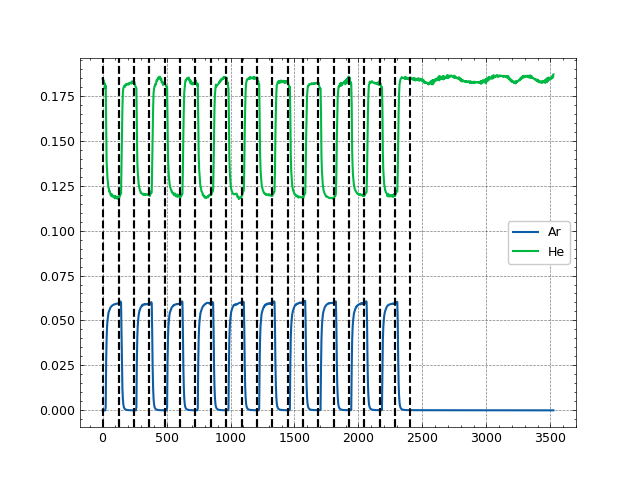

In [9]:
plt.plot(t, n_dot_interp[0], label="Ar")
plt.plot(t, n_dot_interp[1], label="He")
for interval in intervals:
    plt.axvline(interval[0], color="black", linestyle="--")
    plt.axvline(interval[1], color="black", linestyle="--")
plt.legend()

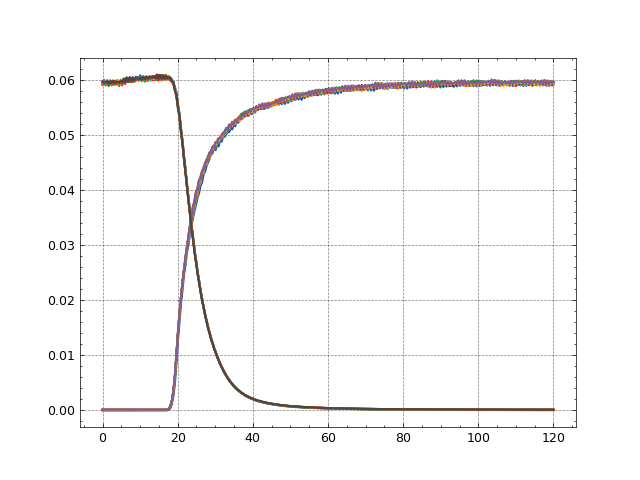

In [10]:
fig = plt.figure()
for interval in intervals:

    t = np.linspace(interval[0], interval[0] + 120, 300)

    n_dot_interp = interp(t)

    plt.plot(t - interval[0], n_dot_interp[0])

plt.savefig("example.svg")